1.导包

In [59]:
import numpy  as np
import  matplotlib.pyplot as plt

2.造数据

In [60]:
#设置随机种子：伪随机，方便复现
np.random.seed(42)
#通过均值矩阵和协方差矩阵，借助np.random.multivariate_normal方法生成随机数矩阵
mean_1 = [1,1]
cov_1 = [[2,0],[0,2]]
x1 = np.random.multivariate_normal(mean_1, cov_1, 10)
y1 = np.zeros(10)

3.输出x1查看

In [61]:
print(x1)

[[ 1.70245989  0.80446475]
 [ 1.91596991  3.15388948]
 [ 0.66885712  0.66888034]
 [ 3.23334418  2.0853166 ]
 [ 0.33606296  1.76729577]
 [ 0.34462841  0.34135867]
 [ 1.34218633 -1.70578687]
 [-1.43940219  0.20480535]
 [-0.43235951  1.44441284]
 [-0.28413996 -0.99729905]]


4.查看x1的散点图

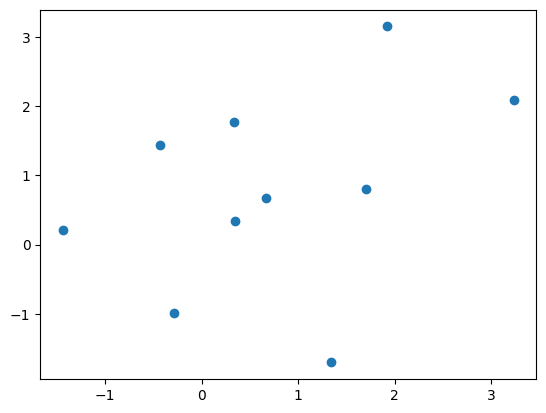

In [62]:
plt.scatter(x1[:,0],x1[:,1])
plt.show()

5.生成类别2的样本

In [63]:
#类别2的特征矩阵
mean_2 = [1,1]
cov_2 = [[-2,0],[0,-2]]
#生成随机数据
x2 = np.random.multivariate_normal(mean_2, cov_2, 10)
y2 = np.ones(10)

C:\Users\binEd\AppData\Local\Temp\ipykernel_13128\3122380911.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  x2 = np.random.multivariate_normal(mean_2, cov_2, 10)


6.合并两个类别的随机数据样本和标签

In [64]:
X = np.concatenate((x1,x2),axis=0)
y = np.concatenate((y1,y2),axis=0)


7.绘制合并后的散点图

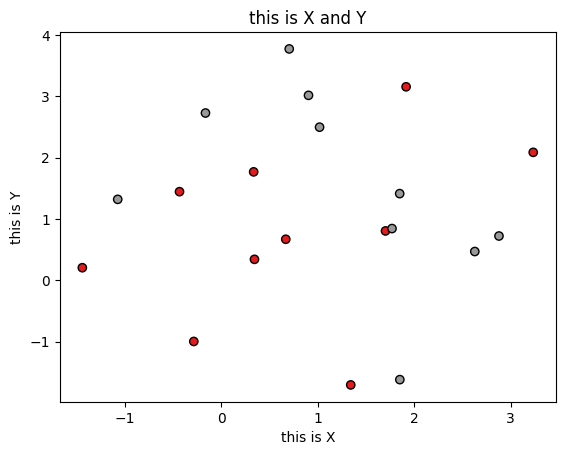

In [65]:
plt.scatter(X[:,0],X[:,1],c=y,cmap = plt.cm.Set1,edgecolors='k')
plt.xlabel("this is X")
plt.ylabel("this is Y")
plt.title("this is X and Y")
plt.show()

8.定义激活函数

In [66]:
#Logistic函数即为Sigmoid函数
def sigmoid(x):
    return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))
        

9.定义逻辑回归类

In [67]:
class RogisticRegression:
    def __init__(self,learning_rate=0.01,max_iter=1000): #传入学习率和最大迭代次数
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        #权重和偏置
        self.weights = None
        self.bias = None
    def fit(self,X,y):
        num_samples,num_features = X.shape
        """
        对于二维数组，X.shape 返回一个元组 (rows, columns)：
            rows 表示数组的行数（通常对应样本数量）
            columns 表示数组的列数（通常对应特征数量）
        """
        #初始化权重和偏置
        self.weights = np.zeros(num_features)
        self.bias = 0
        #梯度下降
        for _ in range(self.max_iter):
            linear_model = np.dot(X,self.weights)+self.bias
            y_pred = sigmoid(linear_model)
            #求导
            dw = (1/num_samples)*np.dot(X.T,y_pred-y)
            db = (1/num_samples)*np.sum(y_pred-y)
            
            self.weights = self.learning_rate*dw
            self.bias = self.learning_rate*db
    def predict_prod(self,x):
        linear_model = np.dot(x,self.weights)+self.bias
        y_pred = sigmoid(linear_model)
        return y_pred
    def predict(self,X,threshold=0.5):
        y_pred_prod = self.predict_prod(X)
        y_pred = np.zeros_like(y_pred_prod)
        y_pred[y_pred_prod > threshold] = 1
        return y_pred

10.调用LogisticRegression类解决分类问题

In [68]:
#创建逻辑回归实例
logreg = RogisticRegression()
logreg.fit(X,y)
X_new = np.array([[1.5,1.5],[-4.0,-2.0]])
y_pred_prob = logreg.predict_prod(X_new)
y_pred = logreg.predict(X_new)
#输出结果
print("Predicted Probabilities:", y_pred_prob)
print("Predicted Labels:", y_pred)

Predicted Probabilities: [0.49882596 0.5021897 ]
Predicted Labels: [0. 1.]
